Cell 1: Import Libraries

In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2: Random Seed (Reproducibility)

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed fixed:", SEED)

Random seed fixed: 42


Cell 3: Check GPU

In [ ]:
import tensorflow as tf

print("TensorFlow Version :", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU Available:", gpus)
else:
    print("Running on CPU")

TensorFlow Version : 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
DATASET_PATH = DATASET_PATH = "/content/drive/MyDrive/Research paper/dataset of pneomunia/processed_dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

Verify Dataset Paths

In [ ]:
print("Train Exists :", os.path.exists(TRAIN_DIR))
print("Validation Exists :", os.path.exists(VAL_DIR))
print("Test Exists :", os.path.exists(TEST_DIR))

Train Exists : True
Validation Exists : True
Test Exists : True


Define Training Configuration

In [ ]:
# ==============================
# Cell 7: Define Training Configuration
# ==============================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

NUM_CLASSES = 3

EPOCHS_INITIAL = 20
EPOCHS_FINE_TUNE = 10

LEARNING_RATE = 1e-4

print("Image Size      :", IMG_SIZE)
print("Batch Size      :", BATCH_SIZE)
print("Number of Classes:", NUM_CLASSES)
print("Learning Rate   :", LEARNING_RATE)

Image Size      : (224, 224)
Batch Size      : 32
Number of Classes: 3
Learning Rate   : 0.0001


Cell 8 — Load Training, Validation & Test Dataset

In [ ]:
import os

print("Train folders :", os.listdir(TRAIN_DIR))
print("Validation folders :", os.listdir(VAL_DIR))
print("Test folders :", os.listdir(TEST_DIR))

Train folders : ['NORMAL', 'BACTERIA', 'VIRUS']
Validation folders : ['NORMAL', 'BACTERIA', 'VIRUS']
Test folders : ['NORMAL', 'BACTERIA', 'VIRUS']


In [ ]:
# ==============================
# Cell 8: Load Dataset
# ==============================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4099 files belonging to 3 classes.
Found 878 files belonging to 3 classes.
Found 879 files belonging to 3 classes.


In [ ]:
# ==============================
# Cell 9: Display Class Information
# ==============================

class_names = train_ds.class_names

print("=" * 40)
print("Class Names")
print("=" * 40)

for i, class_name in enumerate(class_names):
    print(f"{i} : {class_name}")

print("\nNumber of Classes :", len(class_names))

Class Names
0 : BACTERIA
1 : NORMAL
2 : VIRUS

Number of Classes : 3


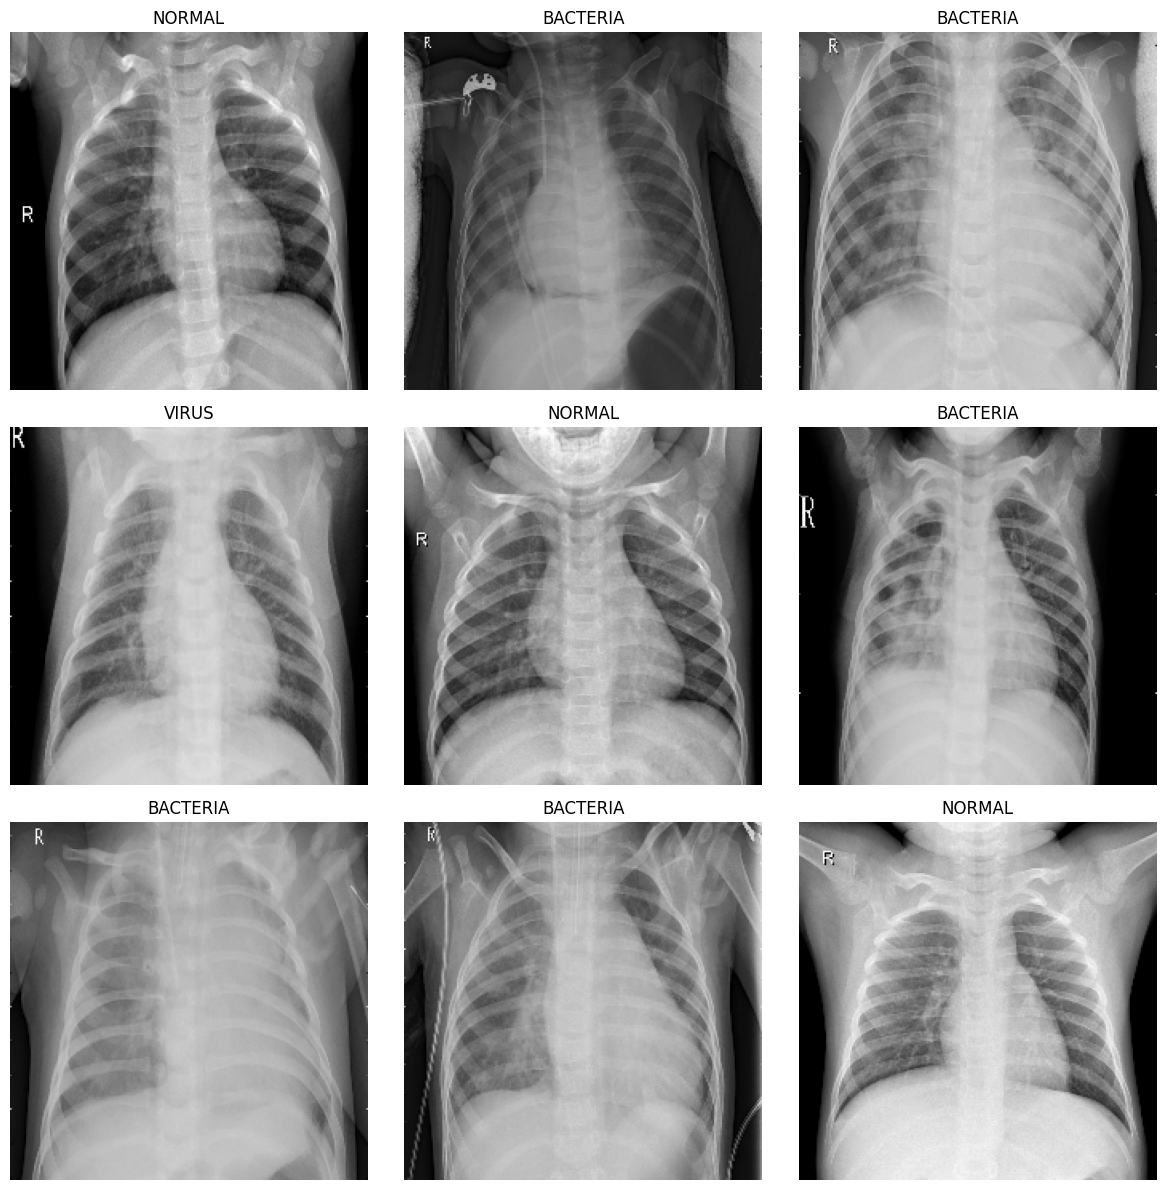

In [ ]:
# ==============================
# Cell 10: Visualize Sample Images
# ==============================

plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# Cell 11: Data Augmentation
# ==============================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
], name="data_augmentation")

print(data_augmentation)

<Sequential name=data_augmentation, built=False>


In [ ]:
# ==============================
# Cell 11: Data Augmentation
# ==============================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
], name="data_augmentation")

print(data_augmentation)

<Sequential name=data_augmentation, built=False>


In [ ]:
# ==============================
# Cell 13: Build EfficientNetB0 Base Model
# ==============================

from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("Base Model Loaded Successfully")
print("Trainable:", base_model.trainable)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model Loaded Successfully
Trainable: False


In [ ]:
# ==============================
# Cell 14: Build Complete Model
# ==============================

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dropout,
    Dense
)

inputs = Input(shape=(224, 224, 3))

# Data Augmentation
x = data_augmentation(inputs)

# EfficientNetB0 Preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Base Model
x = base_model(x, training=False)

# Classification Head
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.30)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = Model(inputs, outputs)

print("Model Created Successfully")

Model Created Successfully


In [ ]:
# ==============================
# Cell 15: Model Summary
# ==============================

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,534 (15.48 MB)

 Trainable params: 6,403 (25.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# ==============================
# Cell 16: Compile Model
# ==============================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# ==============================
# Cell 17: Define Training Callbacks
# ==============================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_efficientnetb0.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    early_stopping,
    checkpoint,
    reduce_lr
]

print("Callbacks created successfully.")

Callbacks created successfully.


In [26]:
# ==============================
# Cell 18: Verify Class Distribution
# ==============================

import os

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} DATASET")

    split_path = os.path.join(DATASET_PATH, split)

    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)

        if os.path.isdir(cls_path):
            print(f"{cls:<10} : {len(os.listdir(cls_path))}")


TRAIN DATASET
BACTERIA   : 1946
NORMAL     : 1108
VIRUS      : 1045

VAL DATASET
BACTERIA   : 417
NORMAL     : 237
VIRUS      : 224

TEST DATASET
BACTERIA   : 417
NORMAL     : 238
VIRUS      : 224


In [25]:
# ==============================
# Cell 17: Compute Class Weights (Fast)
# ==============================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Based on processed training dataset
labels = (
    [0] * 1946 +   # BACTERIA
    [1] * 1108 +   # NORMAL
    [2] * 1045     # VIRUS
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=labels
)

class_weights = {
    i: float(weight) for i, weight in enumerate(class_weights)
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 0.7021240150736554, 1: 1.233152827918171, 2: 1.3074960127591706}


In [27]:
# ==============================
# Cell 18: Compile Model
# ==============================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model compiled successfully.")

✅ Model compiled successfully.


In [28]:
# ==============================
# Cell 19: Define Training Callbacks
# ==============================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_efficientnetb0.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    early_stopping,
    checkpoint,
    reduce_lr
]

print("✅ Callbacks Ready")

✅ Callbacks Ready
